In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv('NKE.csv')

# 2. Convert 'Date' to a standard datetime format and sort it
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)

# 3. Set Date as the index (standard for time-series)
df.set_index('Date', inplace=True)

# 4. We will predict the 'Close' price. Let's isolate it.
close_prices = df[['Close']].values 

# 5. Apply Min-Max Scaling (The math formula mentioned above)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close_prices)

print("Original first 5 prices:\n", close_prices[:5])
print("\nScaled first 5 prices:\n", scaled_data[:5])

Original first 5 prices:
 [[4.47137356]
 [4.22748327]
 [4.47137356]
 [4.44814634]
 [4.44814634]]

Scaled first 5 prices:
 [[0.01223239]
 [0.01074325]
 [0.01223239]
 [0.01209057]
 [0.01209057]]


In [5]:
# --- Continuing from Step 2 ---

# We will use the last 60 days of data to predict the 61st day
time_step = 60 

X = []
y = []

# Loop through the scaled data to create our overlapping chunks
for i in range(time_step, len(scaled_data)):
    # X gets the previous 60 days
    X.append(scaled_data[i-time_step:i, 0])
    # y gets the 61st day (the target)
    y.append(scaled_data[i, 0])

# Convert the lists back to numpy arrays for the AI to read
X, y = np.array(X), np.array(y)

# LSTMs require data to be in 3 Dimensions: [Number of Samples, Time Steps, Features]
# Currently X is 2D: [Samples, Time Steps]. We add the 1 Feature (Close Price).
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print("Shape of X (Inputs):", X.shape)
print("Shape of y (Targets):", y.shape)

Shape of X (Inputs): (6499, 60, 1)
Shape of y (Targets): (6499,)


Training the model... this might take a minute or two! ☕
Epoch 1/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - loss: 0.0032
Epoch 2/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - loss: 0.0013
Epoch 3/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - loss: 0.0011
Epoch 4/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 9.7806e-04
Epoch 5/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - loss: 8.3706e-04
Epoch 6/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - loss: 8.7033e-04
Epoch 7/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - loss: 8.0917e-04
Epoch 8/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - loss: 7.1790e-04
Epoch 9/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - loss: 7.0866e-04
Epoch 10/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - loss: 7.5038e-04
Epoch 11/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - loss: 6.7300e-04
Epoch 12/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - loss: 6.0800e-04
Epoch 13/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - loss: 5.9836e-04
Epoch 

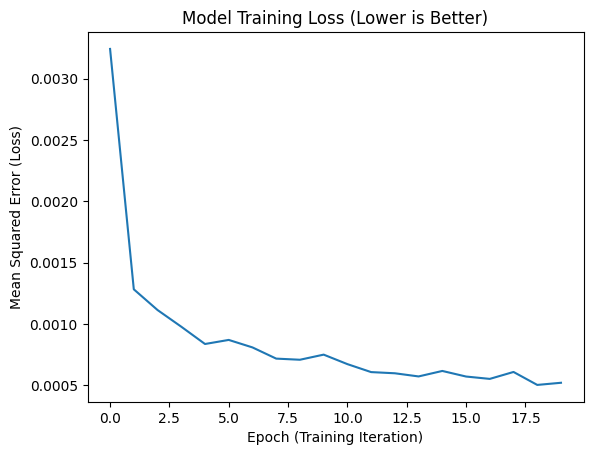

In [7]:
# --- Continuing from Step 3 ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

# 1. Initialize the Neural Network
model = Sequential()

# 2. Add the first LSTM layer (with 50 neurons) 
# return_sequences=True means it passes the full 60-day sequence to the next layer
model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], 1)))

# Add Dropout to prevent overfitting (turns off 20% of neurons randomly)
model.add(Dropout(0.2))

# 3. Add a second LSTM layer
# return_sequences=False because we just want it to output the final condensed information
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# 4. Add the Output Layer (Dense layer with 1 unit because we want exactly 1 predicted price)
model.add(Dense(units=1))

# 5. Compile the Model using the Adam mathematical optimizer and Mean Squared Error loss
model.compile(optimizer='adam', loss='mean_squared_error')

# 6. Train the Model! 
# epochs = 20: The AI will look at the entire dataset 20 times to learn the patterns.
# batch_size = 32: It will process 32 chunks of 60-days at a time before updating its math weights.
print("Training the model... this might take a minute or two! ☕")
history = model.fit(X, y, epochs=20, batch_size=32)
print("Training Complete! 🎉")

# 7. Let's plot the "Loss" to prove the AI actually learned something
plt.plot(history.history['loss'])
plt.title('Model Training Loss (Lower is Better)')
plt.ylabel('Mean Squared Error (Loss)')
plt.xlabel('Epoch (Training Iteration)')
plt.show()

In [9]:
# --- Continuing from Step 4 ---

# 1. Grab the very last 60 days of prices from our scaled dataset
last_60_days = scaled_data[-60:]

# 2. Reshape it so the AI understands it: (1 prediction, 60 days, 1 feature)
# We are creating an array that looks exactly like the ones it trained on
X_predict = np.reshape(last_60_days, (1, 60, 1))

# 3. Ask the AI to predict the next day! (Output will be between 0 and 1)
predicted_price_scaled = model.predict(X_predict)
print(f"Raw AI Output (Scaled): {predicted_price_scaled[0][0]}")

# 4. Reverse the math to get the actual Dollar ($) amount
predicted_price_real = scaler.inverse_transform(predicted_price_scaled)

# 5. Display the final result
print(f"💰 The AI predicts the closing price for the next trading day will be: ${predicted_price_real[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
Raw AI Output (Scaled): 0.373313844203949
💰 The AI predicts the closing price for the next trading day will be: $63.61


Generating predictions for historical data...
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step


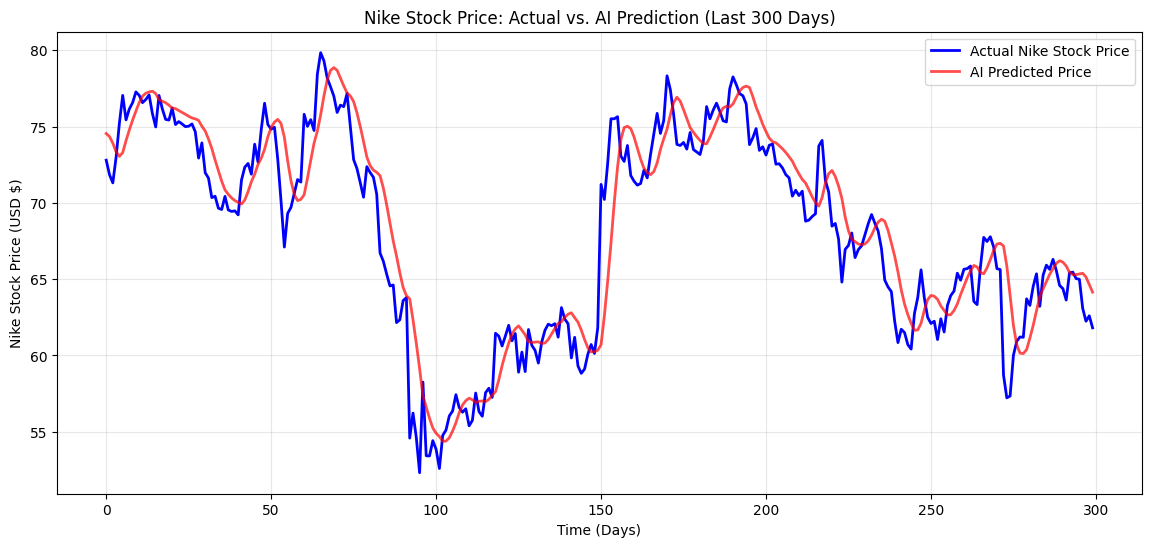

In [11]:
# --- Continuing from Step 5 ---

# 1. Ask the AI to make a prediction for ALL historical data we have
print("Generating predictions for historical data...")
historical_predictions = model.predict(X)

# 2. Reverse the math (Scaling) for both the predictions AND the actual 'y' values
predicted_prices_real = scaler.inverse_transform(historical_predictions)
actual_prices_real = scaler.inverse_transform(y.reshape(-1, 1))

# 3. Create the Graph!
plt.figure(figsize=(14, 6))

# We will plot only the last 300 days. 
# If we plot all 6,500 days, the graph will be too crowded to read!
plt.plot(actual_prices_real[-300:], color='blue', label='Actual Nike Stock Price', linewidth=2)
plt.plot(predicted_prices_real[-300:], color='red', label='AI Predicted Price', alpha=0.7, linewidth=2)

plt.title('Nike Stock Price: Actual vs. AI Prediction (Last 300 Days)')
plt.xlabel('Time (Days)')
plt.ylabel('Nike Stock Price (USD $)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate MSE, RMSE, and MAE
mse = mean_squared_error(actual_prices_real, predicted_prices_real)
rmse = math.sqrt(mse)
mae = mean_absolute_error(actual_prices_real, predicted_prices_real)

print("--- AI Model Performance Metrics ---")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print("------------------------------------")
print(f"Interpretation: On any given day, the AI's prediction is, on average, off by about ${mae:.2f}.")

--- AI Model Performance Metrics ---
Mean Absolute Error (MAE): $1.61
Root Mean Squared Error (RMSE): $2.04
------------------------------------
Interpretation: On any given day, the AI's prediction is, on average, off by about $1.61.


In [14]:
import joblib

# 1. Save the trained LSTM Neural Network
# We use the modern .keras extension for saving TensorFlow models
model.save('nike_lstm_model.keras')
print("✅ Model successfully saved as 'nike_lstm_model.keras'")

# 2. Save the MinMaxScaler object using joblib
# This ensures our live app scales new data exactly the same way!
joblib.dump(scaler, 'nike_scaler.pkl')
print("✅ Scaler successfully saved as 'nike_scaler.pkl'")

✅ Model successfully saved as 'nike_lstm_model.keras'
✅ Scaler successfully saved as 'nike_scaler.pkl'
